# Lab 04 — Fuzzy Logic and ANFIS with Air-Quality Data

**Objective.** Build an expert-rule Mamdani controller and a learned Sugeno ANFIS, then evaluate the ANFIS against linear regression on held-out data.

**Data.** `all_datasets/lab04-AirQuality.csv`.

**Run.** From the course folder, run `cd all_experiments`, start Jupyter, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** Controller checks, the fixed split, model metrics, and plots in `results/lab04/`.

**Workflow**

1. Clean and inspect the data.
2. Build the fuzzy controller.
3. Validate the rule base.
4. Prepare the ANFIS task.
5. Select the ANFIS size on validation data.
6. Evaluate once on the test data.


## Setup

In [1]:
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab04"
RESULTS.mkdir(parents=True, exist_ok=True)

## Question 1 — Clean the data

The UCI Air Quality file is semicolon-separated with a decimal comma, marks missing values
as `-200`, and ends with empty rows. Parse it, turn `-200` into missing values, drop the
empty tail, and report how many usable rows each variable has. Plot temperature against
humidity to see the conditions the controller must cover.

Rows: 9357


,usable rows
T,8991
RH,8991
CO(GT),7674
PT08.S1(CO),8991
PT08.S2(NMHC),8991


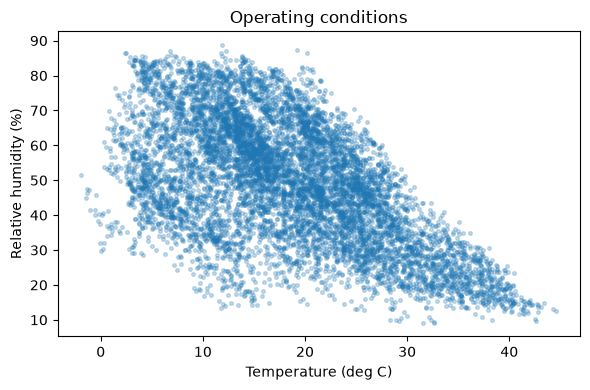

In [2]:
df = pd.read_csv(DATA / "lab04-AirQuality.csv", sep=";", decimal=",")
df = df.dropna(axis="columns", how="all").dropna(how="all")   # empty unnamed columns, empty tail rows
df = df.replace(-200, np.nan)

print("Rows:", len(df))
display(df[["T", "RH", "CO(GT)", "PT08.S1(CO)", "PT08.S2(NMHC)"]].notna().sum().rename("usable rows").to_frame())

ax = df.plot.scatter(x="T", y="RH", s=7, alpha=0.25, figsize=(6, 4))
ax.set(xlabel="Temperature (deg C)", ylabel="Relative humidity (%)", title="Operating conditions")
plt.tight_layout()
plt.savefig(RESULTS / "temperature_humidity.png", dpi=160)

**Result and interpretation.** 9,357 hourly rows remain. Temperature and humidity are present in 8,991 of
them, but the reference CO analyser `CO(GT)` is missing in almost 1,700 rows, so the
regression later uses only rows where the target and both sensors are present.
Temperature spans about 0–45 degrees and humidity 10–90 %, which fixes the ranges of the
controller.

## Question 2 — Build the fuzzy controller

Inputs: temperature and relative humidity. Output: ventilation demand, 0–100 %. Give each
variable three triangular membership functions (the outer two are shoulders), write the
expert rules, and implement Mamdani inference: `min` for AND, `max` to combine rules,
centroid to defuzzify. Plot the memberships.

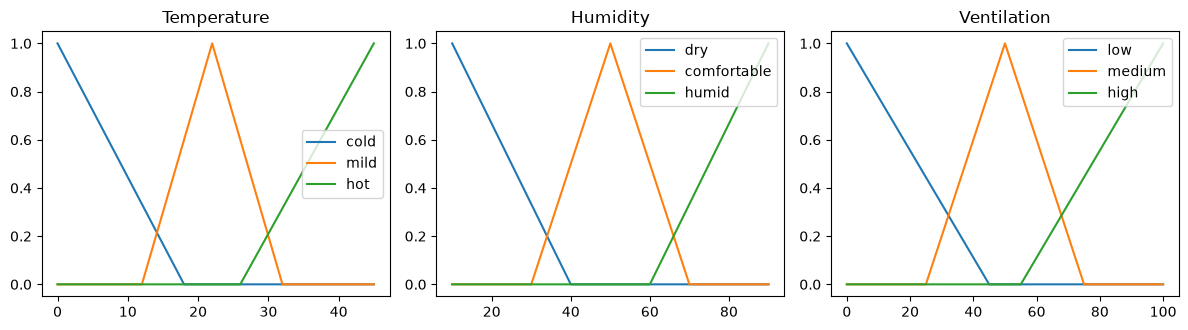

In [3]:
def trimf(x, a, b, c):
    """Triangle with feet a and c and peak b. a == b or b == c makes a shoulder."""
    x = np.asarray(x, dtype=float)
    left = np.ones_like(x) if a == b else np.clip((x - a) / (b - a), 0, 1)
    right = np.ones_like(x) if b == c else np.clip((c - x) / (c - b), 0, 1)
    return np.minimum(left, right)


T_range, RH_range, V_range = np.linspace(0, 45, 451), np.linspace(10, 90, 401), np.linspace(0, 100, 501)
T_sets = {"cold": trimf(T_range, 0, 0, 18), "mild": trimf(T_range, 12, 22, 32), "hot": trimf(T_range, 26, 45, 45)}
RH_sets = {"dry": trimf(RH_range, 10, 10, 40), "comfortable": trimf(RH_range, 30, 50, 70), "humid": trimf(RH_range, 60, 90, 90)}
V_sets = {"low": trimf(V_range, 0, 0, 45), "medium": trimf(V_range, 25, 50, 75), "high": trimf(V_range, 55, 100, 100)}


def degree(universe, membership, value):
    """Membership degree of one crisp value."""
    return float(np.interp(value, universe, membership))


def ventilation(temperature, humidity):
    t = {name: degree(T_range, mf, temperature) for name, mf in T_sets.items()}
    h = {name: degree(RH_range, mf, humidity) for name, mf in RH_sets.items()}
    # Rule strengths: AND is min; rules with the same conclusion combine with max.
    low = max(min(t["cold"], h["dry"]), min(t["cold"], h["comfortable"]))
    medium = max(min(t["mild"], h["dry"]), min(t["mild"], h["comfortable"]), min(t["cold"], h["humid"]))
    high = max(t["hot"], h["humid"])
    # Clip each output set at its rule strength, take the union, return its centroid.
    output = np.maximum.reduce([np.minimum(low, V_sets["low"]), np.minimum(medium, V_sets["medium"]), np.minimum(high, V_sets["high"])])
    return float(np.sum(V_range * output) / np.sum(output))


fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (title, universe, sets) in zip(axes, [("Temperature", T_range, T_sets), ("Humidity", RH_range, RH_sets), ("Ventilation", V_range, V_sets)]):
    for name, membership in sets.items():
        ax.plot(universe, membership, label=name)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fuzzy_memberships.png", dpi=160)

**Result and interpretation.** The three sets of each variable overlap, so every reading belongs to at least
one set and neighbouring rules blend rather than switch. Six rules map temperature and
humidity to low, medium or high ventilation; the centroid of the combined output set is the
crisp percentage.

## Question 3 — Validate the rule base

Evaluate five fixed operating points that have an expected qualitative answer, then compute
the full control surface and check that it is smooth and rises in the right direction.
Save both.

,T_C,RH_pct,expected,ventilation_pct
0,10,30,low,18.9
1,20,50,medium,50.0
2,35,50,high,82.3
3,25,80,high,83.8
4,40,80,high,84.2


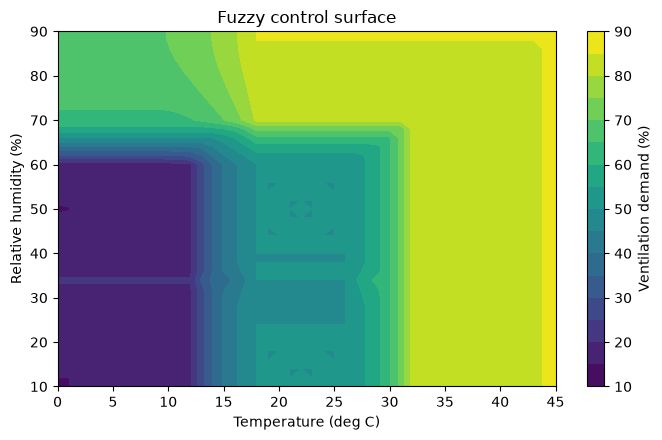

In [4]:
fixed = pd.DataFrame({"T_C": [10, 20, 35, 25, 40], "RH_pct": [30, 50, 50, 80, 80],
                      "expected": ["low", "medium", "high", "high", "high"]})
fixed["ventilation_pct"] = [ventilation(t, h) for t, h in zip(fixed.T_C, fixed.RH_pct)]
fixed.to_csv(RESULTS / "fuzzy_fixed_points.csv", index=False)
display(fixed.round(1))

temperatures, humidities = np.linspace(0, 45, 46), np.linspace(10, 90, 41)
surface = np.array([[ventilation(t, h) for t in temperatures] for h in humidities])

fig, ax = plt.subplots(figsize=(7, 4.5))
contour = ax.contourf(temperatures, humidities, surface, levels=15)
fig.colorbar(contour, label="Ventilation demand (%)")
ax.set(xlabel="Temperature (deg C)", ylabel="Relative humidity (%)", title="Fuzzy control surface")
plt.tight_layout()
plt.savefig(RESULTS / "fuzzy_control_surface.png", dpi=160)

**Result and interpretation.** About 19 % for the cool-dry point, 50 % for the mild-comfortable point and
over 80 % for the hot or humid points: every fixed point lands in its expected band. The
surface rises towards the hot-and-humid corner without steps, because overlapping
memberships blend neighbouring rules.

## Question 4 — Prepare the ANFIS task

Predict the reference CO concentration `CO(GT)` from the two metal-oxide sensors
`PT08.S1(CO)` and `PT08.S2(NMHC)`. Keep complete rows only, split 70/15/15 with seed 42,
standardise the inputs with training statistics only, and save the split.

In [5]:
task = df[["CO(GT)", "PT08.S1(CO)", "PT08.S2(NMHC)"]].dropna()
X = task[["PT08.S1(CO)", "PT08.S2(NMHC)"]].to_numpy()
y = task["CO(GT)"].to_numpy()

train, rest = train_test_split(np.arange(len(task)), test_size=0.30, random_state=42)
val, test = train_test_split(rest, test_size=0.50, random_state=42)
split = pd.Series("train", index=task.index, name="split")
split.iloc[val], split.iloc[test] = "validation", "test"
split.rename_axis("source_row").to_csv(RESULTS / "split.csv")

scaler = StandardScaler().fit(X[train])
Xs = scaler.transform(X)
print({"usable_rows": len(task), "train": len(train), "validation": len(val), "test": len(test)})

{'usable_rows': 7344, 'train': 5140, 'validation': 1102, 'test': 1102}


**Result and interpretation.** 7,344 complete rows give 5,140 training, 1,102 validation and 1,102 test
rows. The scaler sees only the training rows, so nothing from validation or test leaks into
the model.

## Question 5 — Fit two model classes

Train linear regression as the baseline. Implement a first-order Sugeno ANFIS with Gaussian
memberships: the rule outputs are solved by least squares, the membership centres and widths
by L-BFGS-B. Train candidates with two and three memberships per input and select the size
by validation RMSE only. Save `metrics.csv`.

In [6]:
class SugenoANFIS:
    """First-order Sugeno ANFIS: Gaussian memberships, linear rule outputs."""

    def __init__(self, n_mfs=2, ridge=1e-4, maxiter=30):
        self.n_mfs, self.ridge, self.maxiter = n_mfs, ridge, maxiter

    def _weights(self, X, theta):
        """Layers 1-3: memberships -> rule strengths -> normalised strengths."""
        n_features = X.shape[1]
        centers = theta[: n_features * self.n_mfs].reshape(n_features, self.n_mfs)
        widths = np.exp(theta[n_features * self.n_mfs :]).reshape(n_features, self.n_mfs)
        membership = [np.exp(-0.5 * ((X[:, [j]] - centers[j]) / widths[j]) ** 2) for j in range(n_features)]
        strength = np.column_stack([np.prod([membership[j][:, m] for j, m in enumerate(rule)], axis=0)
                                    for rule in product(range(self.n_mfs), repeat=n_features)])
        return strength / (strength.sum(axis=1, keepdims=True) + 1e-12)

    def _design(self, X, theta):
        """Layer 4: every rule contributes weight x (1, x1, x2) to a linear output."""
        weights = self._weights(X, theta)
        inputs = np.column_stack([np.ones(len(X)), X])
        return np.hstack([weights[:, [r]] * inputs for r in range(weights.shape[1])])

    def _solve_outputs(self, X, y, theta):
        Z = self._design(X, theta)
        return np.linalg.solve(Z.T @ Z + self.ridge * np.eye(Z.shape[1]), Z.T @ y)

    def fit(self, X, y):
        n_features = X.shape[1]
        centers = np.array([np.quantile(X[:, j], np.linspace(0.25, 0.75, self.n_mfs)) for j in range(n_features)])
        widths = np.full((n_features, self.n_mfs), max(X.std(), 0.5))
        theta0 = np.r_[centers.ravel(), np.log(widths).ravel()]

        def training_mse(theta):
            return np.mean((y - self._design(X, theta) @ self._solve_outputs(X, y, theta)) ** 2)

        bounds = [(-3, 3)] * centers.size + [(np.log(0.15), np.log(3))] * widths.size
        self.theta_ = minimize(training_mse, theta0, method="L-BFGS-B", bounds=bounds, options={"maxiter": self.maxiter}).x
        self.outputs_ = self._solve_outputs(X, y, self.theta_)
        return self

    def predict(self, X):
        return self._design(X, self.theta_) @ self.outputs_


def scores(name, model):
    row = {"model": name}
    for part, rows in [("validation", val), ("test", test)]:
        prediction = model.predict(Xs[rows])
        row[f"{part}_rmse"] = mean_squared_error(y[rows], prediction) ** 0.5
        row[f"{part}_mae"] = mean_absolute_error(y[rows], prediction)
    return row


linear = LinearRegression().fit(Xs[train], y[train])
candidates = {n: SugenoANFIS(n_mfs=n).fit(Xs[train], y[train]) for n in [2, 3]}

metrics = pd.DataFrame([scores("Linear regression", linear)] + [scores(f"ANFIS-{n}MF", m) for n, m in candidates.items()])
metrics.to_csv(RESULTS / "metrics.csv", index=False)
display(metrics.round(4))

by_model = metrics.set_index("model")
best_n = min(candidates, key=lambda n: by_model.loc[f"ANFIS-{n}MF", "validation_rmse"])
anfis = candidates[best_n]
print(f"Selected by validation RMSE: ANFIS-{best_n}MF")

,model,validation_rmse,validation_mae,test_rmse,test_mae
0,Linear regression,0.5103,0.3722,0.5365,0.3821
1,ANFIS-2MF,0.4550,0.3195,0.4715,0.3264
2,ANFIS-3MF,0.4489,0.3144,0.4672,0.3246


Selected by validation RMSE: ANFIS-3MF


**Result and interpretation.** Both ANFIS candidates beat the linear baseline on validation RMSE, and three
memberships per input is marginally better than two, so it is selected. The choice is made
without looking at the test columns. The class maps onto the five ANFIS layers: Gaussian
memberships (layer 1), rule strengths and their normalisation (layers 2–3) in `_weights`,
linear rule outputs (layer 4) in `_design`, and the weighted sum (layer 5) in `predict`.

## Question 6 — Evaluate once on the test data

Report test RMSE and MAE for the baseline and the selected ANFIS, save the
predicted-versus-actual figure, and say whether the extra complexity is justified.

Test RMSE improvement over linear regression: 12.9%
Saved: ['fuzzy_control_surface.png', 'fuzzy_fixed_points.csv', 'fuzzy_memberships.png', 'metrics.csv', 'predicted_vs_actual.png', 'split.csv', 'temperature_humidity.png']


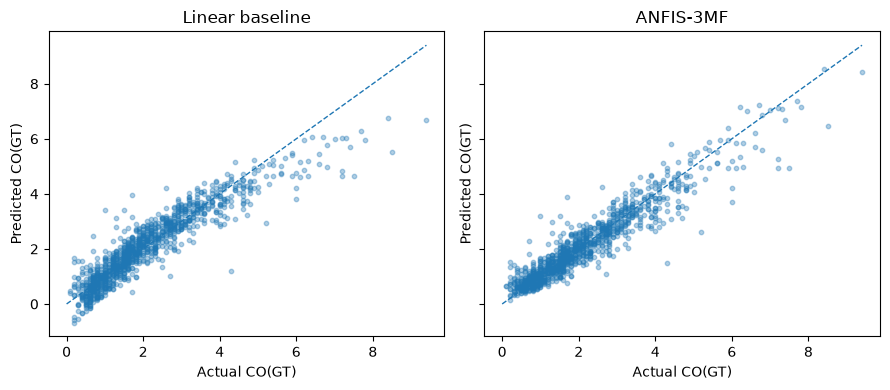

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, (name, model) in zip(axes, [("Linear baseline", linear), (f"ANFIS-{best_n}MF", anfis)]):
    prediction = model.predict(Xs[test])
    ax.scatter(y[test], prediction, s=10, alpha=0.35)
    ax.plot([0, y[test].max()], [0, y[test].max()], "--", linewidth=1)
    ax.set(title=name, xlabel="Actual CO(GT)", ylabel="Predicted CO(GT)")
plt.tight_layout()
plt.savefig(RESULTS / "predicted_vs_actual.png", dpi=160)

improvement = 1 - by_model.loc[f"ANFIS-{best_n}MF", "test_rmse"] / by_model.loc["Linear regression", "test_rmse"]
print(f"Test RMSE improvement over linear regression: {improvement:.1%}")
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

**Result and interpretation.** The selected ANFIS lowers test RMSE by about 13 % relative to linear
regression, and the scatter plot shows why: the sensor response is nonlinear at high CO
levels, where the linear model under-predicts. The extra complexity is justified here. Two
caveats: a random split ignores sensor drift and time order, and the controller and the
regressor solve different problems — one encodes expert policy, the other learns a response
surface from data.

## Submission checklist

- Restart the kernel and run all cells without errors.
- Submit this executed notebook and the generated `results/lab04/` folder.
- Add a short conclusion: Justify the selected ANFIS size, explain why test data cannot guide model selection, and state one limitation of the random split.
